# Importar Librerías y Configurar el Navegador

In [1]:
import pandas as pd
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from bs4 import BeautifulSoup
from time import sleep
import csv
import os
from datetime import datetime
from random import randint
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.common.exceptions import TimeoutException
from webdriver_manager.chrome import ChromeDriverManager
from selenium.common.exceptions import StaleElementReferenceException
import re

from selenium.common.exceptions import NoSuchElementException
from bs4 import BeautifulSoup, NavigableString

# ORQUESTADOR ----------------------------------------------------------------*


In [ ]:
from scraping.extractor_twitter import iniciar_sesion, navegar_a_perfil, extraer_y_guardar_comentarios
#from utils.helpers import configurar_log

# Configuración de logs
#configurar_log()

# FUNCIÓN PRINCIPAL
try:
    # Configuración del navegador
    service = Service(ChromeDriverManager().install())
    driver = webdriver.Chrome(service=service)

    # Iniciar sesión
    iniciar_sesion(driver,user='jamoncayop@gmail.com', pwd='Adaptiv3@*', username='@Jaime1807816689')

    # Navegar al perfil de @Tu_IMSS
    #navegar_a_perfil(driver,'https://x.com/Tu_IMSS')
    navegar_a_perfil(driver, "https://x.com/Tu_IMSS?f=live")
    print("¡Has iniciado sesión y estás en el perfil de @Tu_IMSS!")

    # Extraer y guardar comentarios de los primeros tweets
    #extraer_y_guardar_comentarios(driver, "comentarios_imss_urls_3.csv", max_tweets=20,n_scrolls=3,scroll_pause=2 )
    extraer_y_guardar_comentarios(driver, "comentarios_imss_urls_12.csv" )

except Exception as e:
    print("❌ Error en la ejecución:", e)

finally:
    # Cerrar el navegador
    if driver:
        driver.quit()


✔ Correo ingresado
✔ Nombre de usuario confirmado
✔ Contraseña ingresada
✔ Se hizo clic en 'Iniciar sesión'
¡Has iniciado sesión y estás en el perfil de @Tu_IMSS!
🔄 Scroll fijo #1/1
🔗 Capturadas 7 URLs de tweets (queríamos 20)

🔹 Procesando URL #1/7: https://x.com/Tu_IMSS/status/1946994007411716461

▶️  Abriendo tweet en nueva pestaña: https://x.com/Tu_IMSS/status/1946994007411716461
    🔄 Replies cargados: 0
    🔄 Replies cargados: 0
  🔍 Tamaño de page_source tras spam: 478348
  💡 Extraído: id=id_Mi_padre_tiene_mas_de_7_meses_ replies=0
  👤 Autor original: C B E @CHRIS_MX22 · Jul 20
↪️ [guardar_comentarios] para tweet_id=id_Mi_padre_tiene_mas_de_7_meses_
🔎 oficiales: 0
🔎 spam_cells encontradas: 11, total spam artículos: 5
🔎 total candidatos tras unir: 4
→ auténticas tras filtrar y recortar a 4/0
🔄 Guardando respuesta auténtica #1
🔄 Guardando respuesta auténtica #2
🔄 Guardando respuesta auténtica #3
🔄 Guardando respuesta auténtica #4
  🔙 Cerrando pestaña y volviendo…

🔹 Procesando URL 

In [ ]:
from scraping.extractor_twitter import iniciar_sesion, navegar_a_perfil, extraer_y_guardar_comentarios

# FUNCIÓN PRINCIPAL
try:
    # Configuración del navegador
    service = Service(ChromeDriverManager().install())
    driver = webdriver.Chrome(service=service)

    # Iniciar sesión
    iniciar_sesion(driver,user='jamoncayop@gmail.com', pwd='Adaptiv3@*', username='@Jaime1807816689')

    # Navegar al perfil de @Tu_IMSS
    navegar_a_perfil(driver, "https://x.com/Tu_IMSS?f=live")

    # Extraer y guardar comentarios de los primeros tweets
    extraer_y_guardar_comentarios(driver, "comentarios_imss_urls_3.csv", max_tweets=20,n_scrolls=3,scroll_pause=2 )

except Exception as e:
    print(" Error en la ejecución:", e)

finally:
    # Cerrar el navegador
    if driver:
        driver.quit()


In [ ]:



def procesar_tweet_por_url(driver, url, tweets_procesados, writer):
    print(f"\n▶️  Abriendo tweet en nueva pestaña: {url}")
    # 1) Abrir en pestaña nueva y cambiar contexto
    driver.execute_script("window.open(arguments[0], '_blank');", url)
    driver.switch_to.window(driver.window_handles[-1])
    WebDriverWait(driver, 15).until(lambda d: "/status/" in d.current_url)
    sleep(1)

    # 2) Reveal inicial de replies y posible spam
    for i in range(3):
        driver.execute_script("window.scrollBy(0, 800);")
        sleep(0.7)
    try:
        spam_btn = driver.find_element(
            By.XPATH, "//span[normalize-space(text())='Show probable spam']"
        )
        driver.execute_script("arguments[0].scrollIntoView({block:'center'});", spam_btn)
        sleep(0.5)
        spam_btn.click()
        sleep(1)
    except NoSuchElementException:
        pass

    # 3) Bucle hasta que ya no cargue más replies
    prev_count = -1
    while True:
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        sleep(1)

        # Capturamos el HTML y contamos replies (artículos menos el original)
        html = driver.page_source
        soup_tmp = BeautifulSoup(html, "html.parser")
        conv = soup_tmp.find("div", {
            "role": "region",
            "aria-label": re.compile(r"Timeline: Conversation")
        })
        loaded = (len(conv.find_all("article", {"data-testid": "tweet"})) - 1) if conv else 0

        print(f"    🔄 Replies cargados: {loaded}")
        if loaded == prev_count:
            break
        prev_count = loaded

    # 4) Ya con todo cargado, parseamos el resultado final
    print(f"  🔍 Tamaño de page_source tras spam: {len(driver.page_source)}")
    soup = BeautifulSoup(driver.page_source, "html.parser")

    # 5) Extraemos datos del tweet principal
    tweet_id, tweet_text, fecha_pub, replies, reposts, likes, views = extraer_datos_tweet(soup)
    print(f"  💡 Extraído: id={tweet_id} replies={replies}")

    # 6) Evitamos duplicados
    if tweet_id in tweets_procesados:
        print("  ⚠️ ya procesado, cierro y regreso.")
        driver.close()
        driver.switch_to.window(driver.window_handles[0])
        return
    tweets_procesados.add(tweet_id)

    # 7) Capturamos autor original
    owner_tag = soup.find("article", {"data-testid": "tweet"}) \
                    .find("div", {"data-testid": "User-Name"})
    tweet_owner_raw = owner_tag.get_text(" ", strip=True) if owner_tag else ""
    print(f"  👤 Autor original: {tweet_owner_raw}")

    # 8) Guardamos todos los comentarios ya cargados
    guardar_comentarios(
        tweet_id, tweet_text, soup, writer,
        fecha_pub, replies, reposts, likes, views,
        tweet_owner_raw
    )

    # 9) Cerramos pestaña y volvemos
    print("  🔙 Cerrando pestaña y volviendo…")
    driver.close()
    driver.switch_to.window(driver.window_handles[0])
    



In [ ]:
name = "jaime"

# Nube de palabras

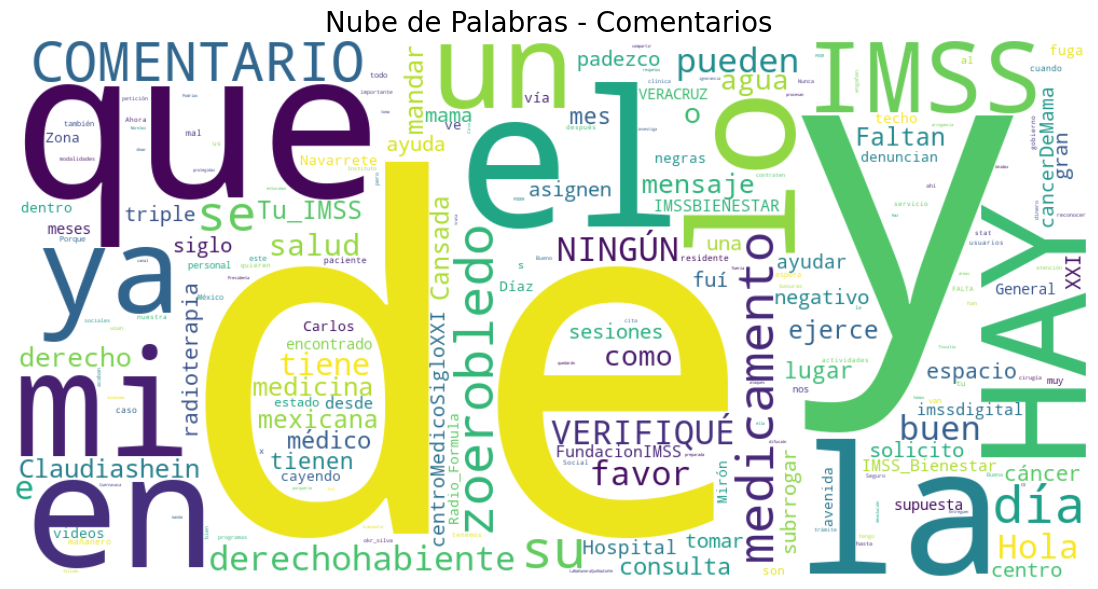

In [6]:
import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Leer el archivo CSV
df = pd.read_csv("db/tweets_limpios.csv")

# Combinar todos los comentarios
texto = " ".join(str(c) for c in df["comentario"].dropna())

# Stopwords en español
stopwords = set(STOPWORDS)
stopwords.update(["https", "rt", "t.co", "si", "no", "tener", "ser", "estar", "del", "por", "para", "con", "más", "menos"])

# Crear y mostrar la nube de palabras
wordcloud = WordCloud(width=1000, height=500, background_color="white", stopwords=stopwords, collocations=False).generate(texto)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de Palabras - Comentarios", fontsize=20)
plt.show()


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Dtweet_id             227 non-null    object 
 1   tweet_text            227 non-null    object 
 2   comentario            227 non-null    object 
 3   comentario_autor      227 non-null    object 
 4   fecha_publicacion     227 non-null    object 
 5   timestamp_extraccion  227 non-null    object 
 6   replies               214 non-null    float64
 7   reposts               227 non-null    int64  
 8   likes                 227 non-null    int64  
 9   views                 227 non-null    int64  
 10  tweet_id_nuevo        227 non-null    int64  
 11  clasificacion         12 non-null     object 
dtypes: float64(1), int64(4), object(7)
memory usage: 21.4+ KB


# parte 2 Análisis de sentimientos

In [15]:
!find . -name "*.pyc" -delete
!find . -name "__pycache__" -exec rm -r {} +

Acceso denegado: .
No se encuentra el archivo: -NAME
No se encuentra el archivo: -DELETE
Acceso denegado: .
No se encuentra el archivo: -NAME
No se encuentra el archivo: -EXEC
No se encuentra el archivo: RM
No se encuentra el archivo: -R
No se encuentra el archivo: {}
No se encuentra el archivo: +


In [16]:
import pandas as pd
from limpieza.preprocesamiento import limpiar_texto
from limpieza.preprocesamiento import limpiar_comentario
from modelos.modelo_huggingface import analizar_comentario
#from limpieza.preprocesamiento import limpiar_comentario

# Cargar datos limpios
df = pd.read_csv("db/tweets_limpios.csv")

# Limpiar comentarios (si tienes lógica propia)
#df["comentario_limpio"] = df["comentario"].apply(lambda x: limpiar_texto(str(x)))
df["comentario_limpio"] = df["comentario"].apply(lambda x: limpiar_comentario(str(x)))

# Analizar sentimiento y temas
resultados = df["comentario_limpio"].apply(analizar_comentario)

# Expandir resultados a columnas
df["sentimiento"] = resultados.apply(lambda x: x["sentimiento"])
df["temas"] = resultados.apply(lambda x: ", ".join(x["temas"]))

# Guardar resultados
df.to_csv("db/tweets_analizados_por_huggingface.csv", index=False)

print("Análisis completado. Archivo guardado en db/tweets_analizados_por_huggingface.csv")


ImportError: cannot import name 'limpiar_comentario' from 'limpieza.preprocesamiento' (c:\Users\ASUS\Desktop\GIT\ProyectoIMSS\ApiComentariosIMSS\limpieza\preprocesamiento.py)